# Objetivo do trabalho
Uso da ResNet18 para detecção de cancer de intestino

### Download do LC25000 através do kaggle

In [2]:
from google.colab import files
!pip install -q kaggle

In [3]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip

def unzip_support_functions_in_colab():
    !kaggle datasets download -d gabrielcruzvazsantos/colon-detection-support-functions
    !unzip -q colon-detection-support-functions.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()
    unzip_support_functions_in_colab()

In [4]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.74G/1.76G [00:12<00:00, 40.3MB/s]
100% 1.76G/1.76G [00:12<00:00, 149MB/s] 
Dataset URL: https://www.kaggle.com/datasets/gabrielcruzvazsantos/colon-detection-support-functions
License(s): unknown
  0% 0.00/4.00k [00:00<?, ?B/s]
100% 4.00k/4.00k [00:00<00:00, 12.8MB/s]


## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

In [5]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders
from train_and_test_model import train_model, test_model


In [6]:
import torch
import torchvision
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns


### Datasets e dataLoader

In [7]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 28429.10it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [8]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test)

### Modelo e treinamento
- Resnet18
- Canais de entrada - imagem RGB: 3
- Saída - Problema de classificação binária: 2
- Taxa de aprendizado: 1e-4

In [9]:
in_channels = 3
output_features = 2
learning_rate = 1e-4

In [10]:
model = torchvision.models.resnet18(num_classes=output_features)

In [11]:
model = model.to("cuda")

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer)

Epoch 1: Train Loss = 0.2607 | Val Loss = 0.2765
Epoch 2: Train Loss = 0.0969 | Val Loss = 0.1120
Epoch 3: Train Loss = 0.0722 | Val Loss = 0.1036
Epoch 4: Train Loss = 0.0584 | Val Loss = 0.1510
Epoch 5: Train Loss = 0.0450 | Val Loss = 0.1711
Epoch 6: Train Loss = 0.0402 | Val Loss = 0.4673
Epoch 7: Train Loss = 0.0297 | Val Loss = 0.1043
Epoch 8: Train Loss = 0.0250 | Val Loss = 0.1152
Epoch 9: Train Loss = 0.0273 | Val Loss = 0.0564
Epoch 10: Train Loss = 0.0224 | Val Loss = 0.2101


#### imprimindo resultados do treinamento e validação

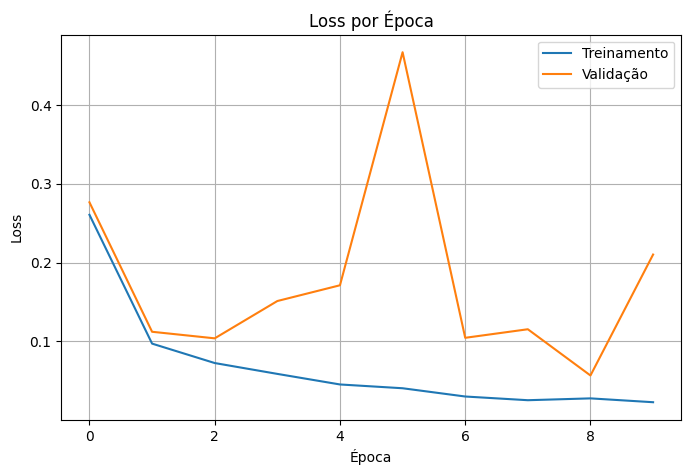

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Testando modelo

In [16]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 0.9855
Precisão (weighted): 0.9857
Recall (weighted): 0.9855
F1-score (weighted): 0.9855
Matriz de Confusão:
[[996   4]
 [ 25 975]]


In [17]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.9855 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9857 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.9855 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9855 │
╘═════════════════════╧═════════╛


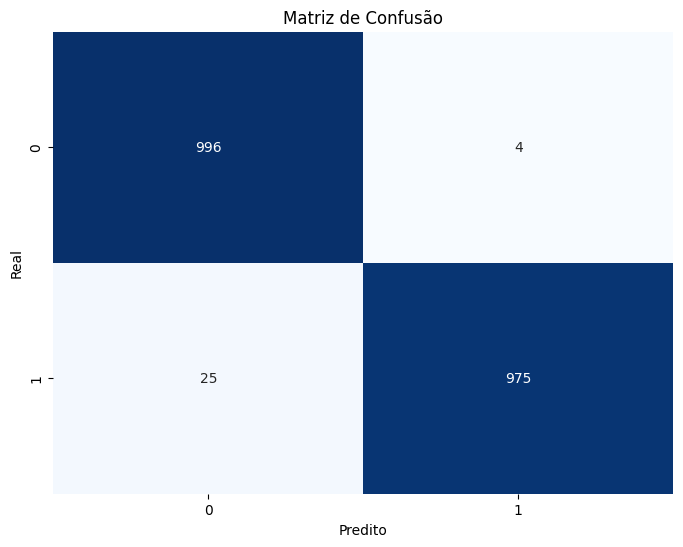

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()